# Discretizing Mixture Similarity

Found 58 CID-like columns.

[ALL ROWS] Descriptive statistics (# of numeric CIDs per row):
count    925.000000
mean      21.780541
std        8.688603
min        1.000000
25%       19.000000
50%       20.000000
75%       30.000000
max       43.000000
dtype: float64

[ALL ROWS] Counts by number of numeric CIDs per row:
1: 7
4: 14
5: 6
6: 6
7: 6
8: 6
9: 6
10: 174
12: 1
15: 2
19: 74
20: 208
30: 408
40: 5
43: 2


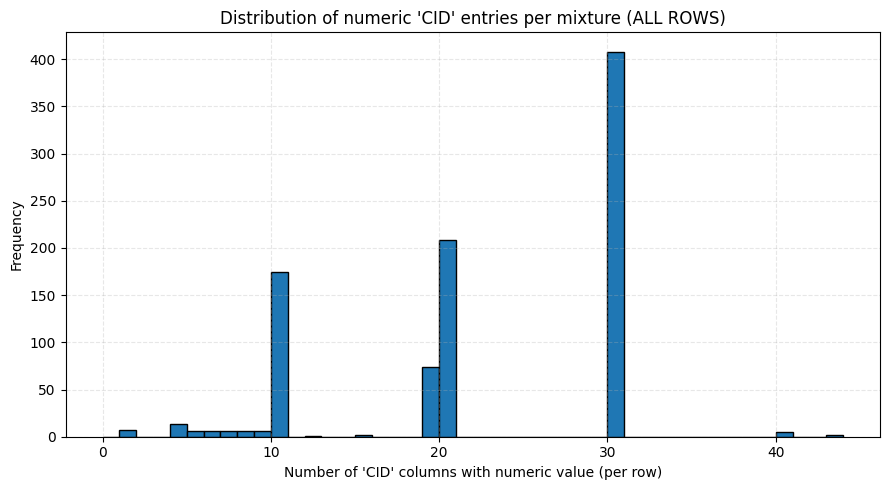

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

IN_CSV = "Mixure_Definitions_Training_set.csv"

CID_REGEX = re.compile(r"^cid(\.\d+)?$", re.IGNORECASE)

def is_numeric_series(s: pd.Series) -> pd.Series:
    s_norm = s.astype(str).str.replace("\u00A0", " ", regex=False).str.strip()
    s_norm = s_norm.replace({"": np.nan})
    return pd.to_numeric(s_norm, errors="coerce").notna()

def main():
    df = pd.read_csv(
        IN_CSV,
        dtype=str,
        engine="python",
        keep_default_na=False,
        na_values=[],
    )

    cid_cols = [c for c in df.columns if CID_REGEX.match(c.strip())]

    if len(cid_cols) <= 1 and df.shape[1] > 2:
        cid_cols = list(df.columns[2:])
        print("Fallback: using all columns after the first two as CID columns.")

    if not cid_cols:
        raise SystemExit("Could not identify CID columns. Check the header names.")

    print(f"Found {len(cid_cols)} CID-like columns.")
    # Extract those columns
    cid_df = df[cid_cols].copy()

    numeric_flags = cid_df.apply(is_numeric_series)
    numeric_count = numeric_flags.sum(axis=1)
    df["CID_numeric_count"] = numeric_count

    print("\n[ALL ROWS] Descriptive statistics (# of numeric CIDs per row):")
    print(numeric_count.describe())
    vc_all = numeric_count.value_counts().sort_index()
    print("\n[ALL ROWS] Counts by number of numeric CIDs per row:")
    for k, v in vc_all.items():
        print(f"{int(k)}: {int(v)}")

    bins_all = range(0, int(numeric_count.max()) + 2) if len(numeric_count) else [0, 1]
    plt.figure(figsize=(9, 5))
    plt.hist(numeric_count, bins=bins_all, edgecolor="black")
    plt.xlabel("Number of 'CID' columns with numeric value (per row)")
    plt.ylabel("Frequency")
    plt.title("Distribution of numeric 'CID' entries per mixture (ALL ROWS)")
    plt.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


Missing CID→(SMILES/Name) mappings — Mixture 1: 1271 entries; Mixture 2: 1168 entries.
Quartile cutpoints used for categories: {'min': 0.076923077, 'q25': 0.461538462, 'q50': 0.576923077, 'q75': 0.6833, 'max': 0.923076923}
Wrote training_pairs_discretization.csv (includes 'answer' categorical labels).


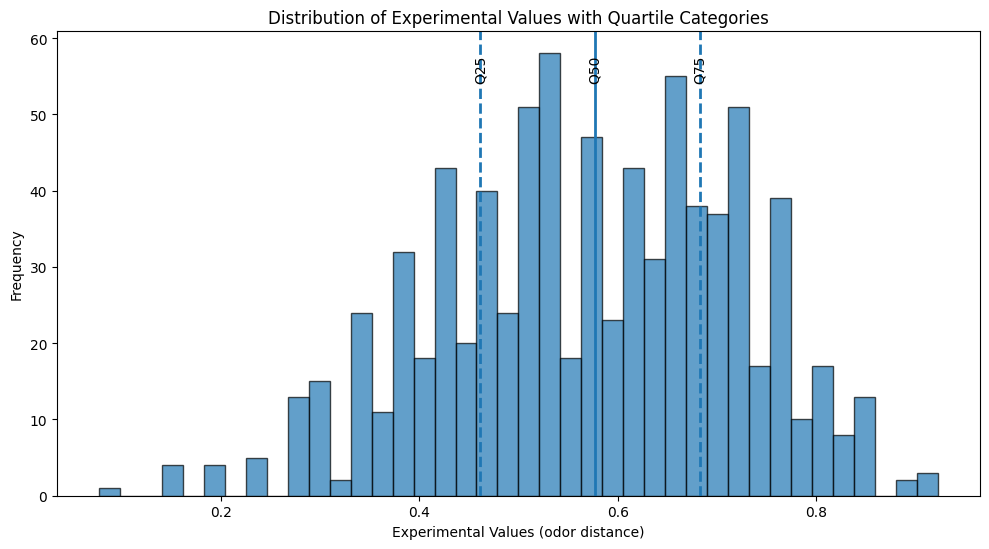

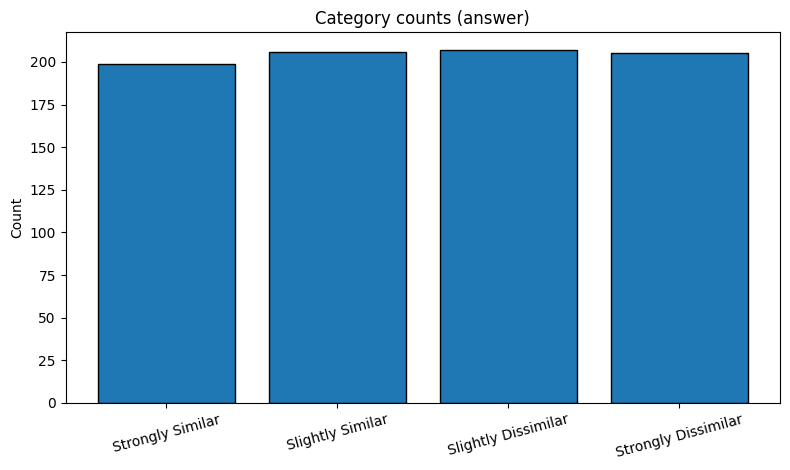

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DEFS_CSV   = "Mixure_Definitions_Training_set.csv"
PAIRS_CSV  = "TrainingData_mixturedist.csv"
CIDMAP_CSV = "CID_map.csv"

OUT_CSV    = "training_pairs_discretization.csv"

DELIM = ";"  
CID_REGEX = re.compile(r"^cid(\.\d+)?$", re.IGNORECASE)

CATEGORY_LABELS = [
    "Strongly Similar",
    "Slightly Similar",
    "Slightly Dissimilar",
    "Strongly Dissimilar",
]

def _normalize_str_series(s: pd.Series) -> pd.Series:
    """Trim, convert NBSP to space, keep blanks as blanks."""
    return (
        s.astype(str)
         .str.replace("\u00A0", " ", regex=False)
         .str.strip()
    )

def _normalize_str(val) -> str:
    if val is None:
        return ""
    return str(val).replace("\u00A0", " ").strip()

def _numeric_frame(df: pd.DataFrame) -> pd.DataFrame:
    """Return numeric view of df (NaN where not numeric)."""
    df_norm = df.apply(_normalize_str_series)
    df_norm = df_norm.replace({"": np.nan})
    return df_norm.apply(pd.to_numeric, errors="coerce")

def _find_cid_columns(defs: pd.DataFrame) -> list[str]:
    """Find all CID-like columns; fallback to all columns after the first two."""
    cid_cols = [c for c in defs.columns if CID_REGEX.match(c.strip())]
    if len(cid_cols) <= 1 and defs.shape[1] > 2:
        # Fallback for files that didn't keep duplicate headers distinctly
        cid_cols = list(defs.columns[2:])
        print("Fallback: using all columns after the first two as CID columns.")
    if not cid_cols:
        raise SystemExit("Could not identify CID columns in the definitions file.")
    return cid_cols

def load_defs_with_counts_and_lists() -> pd.DataFrame:
    """
    Load Mixure_Definitions_Training_set.csv and return a map with:
      Dataset, Mixture Label, CID_count, CID_list (semicolon-separated)
    """
    defs = pd.read_csv(
        DEFS_CSV, dtype=str, engine="python", keep_default_na=False, na_values=[]
    )

    if "Dataset" not in defs.columns or "Mixture Label" not in defs.columns:
        raise SystemExit("Definitions file must contain 'Dataset' and 'Mixture Label' columns.")

    cid_cols = _find_cid_columns(defs)

    cid_num = _numeric_frame(defs[cid_cols])

    cid_count = cid_num.notna().sum(axis=1).astype(int)

    def row_to_list(row) -> str:
        items = []
        for v in row:
            if pd.notna(v):
                try:
                    fv = float(v)
                    items.append(str(int(fv)) if fv.is_integer() else str(fv))
                except Exception:
                    items.append(str(v))
        return DELIM.join(items)

    cid_list = cid_num.apply(row_to_list, axis=1)

    defs_map = pd.DataFrame({
        "Dataset": _normalize_str_series(defs["Dataset"]),
        "Mixture Label": _normalize_str_series(defs["Mixture Label"]),
        "CID_count": cid_count,
        "CID_list": cid_list
    }).drop_duplicates(subset=["Dataset", "Mixture Label"], keep="first").reset_index(drop=True)

    return defs_map

def add_counts_and_lists_to_pairs(defs_map: pd.DataFrame) -> pd.DataFrame:
    """
    Read TrainingData_mixturedist.csv and left-join CID_count and CID_list
    for Mixture 1 and Mixture 2 → add CID_count_1/2 and CID_Mixture_1/2
    """
    pairs = pd.read_csv(
        PAIRS_CSV, dtype=str, engine="python", keep_default_na=False, na_values=[]
    )

    for col in ["Dataset", "Mixture 1", "Mixture 2"]:
        if col not in pairs.columns:
            raise SystemExit(f"Pairs file must contain '{col}' column.")

    pairs["Dataset"]   = _normalize_str_series(pairs["Dataset"])
    pairs["Mixture 1"] = _normalize_str_series(pairs["Mixture 1"])
    pairs["Mixture 2"] = _normalize_str_series(pairs["Mixture 2"])

    dm = defs_map.copy()
    dm["Dataset"]       = _normalize_str_series(dm["Dataset"])
    dm["Mixture Label"] = _normalize_str_series(dm["Mixture Label"])

    m1 = dm.rename(columns={"Mixture Label": "Mixture 1", "CID_count": "CID_count_1", "CID_list": "CID_Mixture_1"})
    m2 = dm.rename(columns={"Mixture Label": "Mixture 2", "CID_count": "CID_count_2", "CID_list": "CID_Mixture_2"})

    out = pairs.merge(m1, on=["Dataset", "Mixture 1"], how="left") \
               .merge(m2, on=["Dataset", "Mixture 2"], how="left")

    # Ensure numeric dtype for counts
    out["CID_count_1"] = pd.to_numeric(out["CID_count_1"], errors="coerce")
    out["CID_count_2"] = pd.to_numeric(out["CID_count_2"], errors="coerce")

    return out

def build_cid_map(df_map: pd.DataFrame) -> tuple[dict, dict]:
    """
    Return two dicts keyed by normalized CID string:
      cid -> Canonical SMILES
      cid -> IUPAC Name
    """
    lower = {c.lower(): c for c in df_map.columns}
    cid_col  = lower.get("cid")
    smi_col  = lower.get("canonical smiles") or lower.get("canonical_smiles")
    name_col = lower.get("iupac name") or lower.get("iupac_name")

    if not cid_col or not smi_col or not name_col:
        raise SystemExit("CID_map.csv must include 'CID', 'Canonical SMILES', and 'IUPAC Name' columns.")

    cid_to_smi, cid_to_name = {}, {}
    for _, row in df_map.iterrows():
        raw_cid = _normalize_str(row[cid_col])
        cid_digits = "".join(ch for ch in raw_cid if ch.isdigit())
        if not cid_digits:
            continue
        smi = _normalize_str(row[smi_col])
        nm  = _normalize_str(row[name_col]).rstrip(",")  # strip trailing comma if present
        cid_to_smi[cid_digits]  = smi
        cid_to_name[cid_digits] = nm
    return cid_to_smi, cid_to_name

def split_cid_list(cell: str) -> list[str]:
    """Split a semicolon-separated CID cell into a clean list of digit strings."""
    s = _normalize_str(cell)
    if not s:
        return []
    parts = [p.strip() for p in s.split(DELIM)]
    cleaned = []
    for p in parts:
        if not p:
            continue
        digits = "".join(ch for ch in p if ch.isdigit())
        if digits:
            cleaned.append(digits)
    return cleaned

def map_cid_lists_to_smiles_names(pairs: pd.DataFrame, cid_to_smi: dict, cid_to_name: dict) -> pd.DataFrame:
    """Add SMILES_1 / compound.name_1 / SMILES_2 / compound.name_2 columns."""
    smiles_1, names_1, smiles_2, names_2 = [], [], [], []
    miss1 = miss2 = 0

    for col in ["CID_Mixture_1", "CID_Mixture_2"]:
        if col not in pairs.columns:
            pairs[col] = ""

    for _, row in pairs.iterrows():
        cids1 = split_cid_list(row["CID_Mixture_1"])
        cids2 = split_cid_list(row["CID_Mixture_2"])

        s1_list, n1_list = [], []
        for cid in cids1:
            s1 = cid_to_smi.get(cid, "")
            n1 = cid_to_name.get(cid, "")
            if not s1 or not n1:
                miss1 += 1
            s1_list.append(s1)
            n1_list.append(n1)

        s2_list, n2_list = [], []
        for cid in cids2:
            s2 = cid_to_smi.get(cid, "")
            n2 = cid_to_name.get(cid, "")
            if not s2 or not n2:
                miss2 += 1
            s2_list.append(s2)
            n2_list.append(n2)

        smiles_1.append(DELIM.join(s1_list))
        names_1.append(DELIM.join(n1_list))
        smiles_2.append(DELIM.join(s2_list))
        names_2.append(DELIM.join(n2_list))

    pairs["SMILES_1"] = smiles_1
    pairs["compound.name_1"] = names_1
    pairs["SMILES_2"] = smiles_2
    pairs["compound.name_2"] = names_2

    print(f"Missing CID→(SMILES/Name) mappings — Mixture 1: {miss1} entries; Mixture 2: {miss2} entries.")
    return pairs

def add_quartile_categories(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """
    Compute quartiles on Experimental Values (coerced to float) and assign:
      [min, q25) -> Strongly Similar
      [q25, q50) -> Slightly Similar
      [q50, q75) -> Slightly Dissimilar
      [q75, max] -> Strongly Dissimilar
    Returns df with new 'answer' column and a dict of cutpoints.
    """
    if "Experimental Values" not in df.columns:
        raise SystemExit("'Experimental Values' column not found in pairs table.")

    vals = pd.to_numeric(df["Experimental Values"], errors="coerce")
    df = df.copy()
    df["Experimental Values"] = vals

    valid = vals.dropna()
    if valid.empty:
        raise SystemExit("No numeric Experimental Values to categorize.")

    q25, q50, q75 = valid.quantile([0.25, 0.50, 0.75]).values
    vmin, vmax = float(valid.min()), float(valid.max())

    bins = [-np.inf, q25, q50, q75, np.inf]
    labels = CATEGORY_LABELS

    df["answer"] = pd.cut(df["Experimental Values"], bins=bins, labels=labels, include_lowest=True, right=False)

    cuts = {"min": vmin, "q25": float(q25), "q50": float(q50), "q75": float(q75), "max": vmax}
    print("Quartile cutpoints used for categories:", cuts)
    return df, cuts

def plot_numeric_with_categories(vals: pd.Series, answers: pd.Series, cuts: dict):
    """
    Plot histogram of Experimental Values with vertical lines for quartiles and
    a legend indicating category mapping.
    """
    valid = vals.dropna()
    if valid.empty:
        print("No numeric Experimental Values to plot.")
        return

    plt.figure(figsize=(10, 5.6))
    bins = 40
    plt.hist(valid, bins=bins, edgecolor="black", alpha=0.7)
    plt.xlabel("Experimental Values (odor distance)")
    plt.ylabel("Frequency")
    plt.title("Distribution of Experimental Values with Quartile Categories")

    for key, style in zip(["q25", "q50", "q75"], ["--", "-", "--"]):
        x = cuts[key]
        plt.axvline(x, linestyle=style, linewidth=2)
        plt.text(x, plt.ylim()[1]*0.95, key.upper(), rotation=90, va="top", ha="center")

    plt.tight_layout()
    plt.show()

    cat_counts = answers.value_counts().reindex(CATEGORY_LABELS, fill_value=0)
    plt.figure(figsize=(8, 4.8))
    plt.bar(cat_counts.index, cat_counts.values, edgecolor="black")
    plt.ylabel("Count")
    plt.title("Category counts (answer)")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

def main():
    defs_map = load_defs_with_counts_and_lists()

    pairs_with = add_counts_and_lists_to_pairs(defs_map)

    cidmap_df = pd.read_csv(CIDMAP_CSV, dtype=str, engine="python", keep_default_na=False, na_values=[])
    cid_to_smi, cid_to_name = build_cid_map(cidmap_df)
    pairs_full = map_cid_lists_to_smiles_names(pairs_with, cid_to_smi, cid_to_name)

    pairs_labeled, cuts = add_quartile_categories(pairs_full)

    pairs_labeled.to_csv(OUT_CSV, index=False)
    print(f"Wrote {OUT_CSV} (includes 'answer' categorical labels).")

    plot_numeric_with_categories(pairs_labeled["Experimental Values"], pairs_labeled["answer"], cuts)

if __name__ == "__main__":
    main()
